In [1]:
from google.colab import files
uploaded =files.upload()

Saving Food_Delivery_Times.csv to Food_Delivery_Times.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv('/content/Food_Delivery_Times.csv')

df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [5]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove null values
df.dropna(inplace=True)

df.shape

(883, 9)

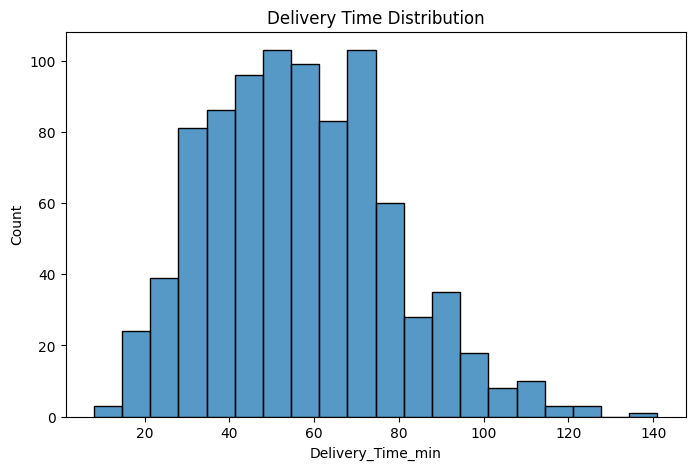

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Delivery_Time_min'], bins=20)
plt.title('Delivery Time Distribution')
plt.show()

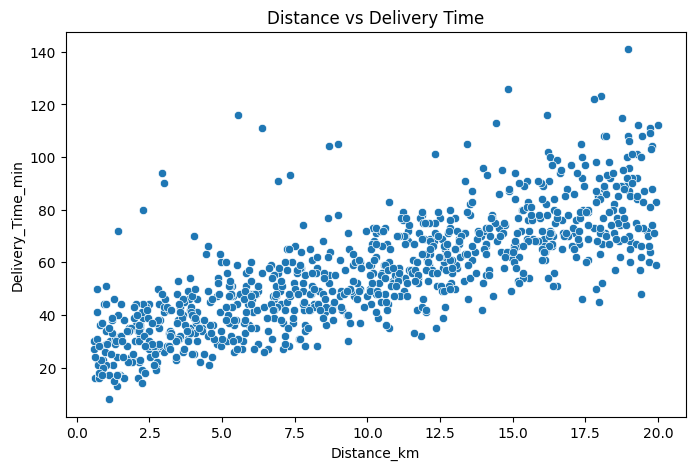

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Distance_km', y='Delivery_Time_min', data=df)
plt.title('Distance vs Delivery Time')
plt.show()

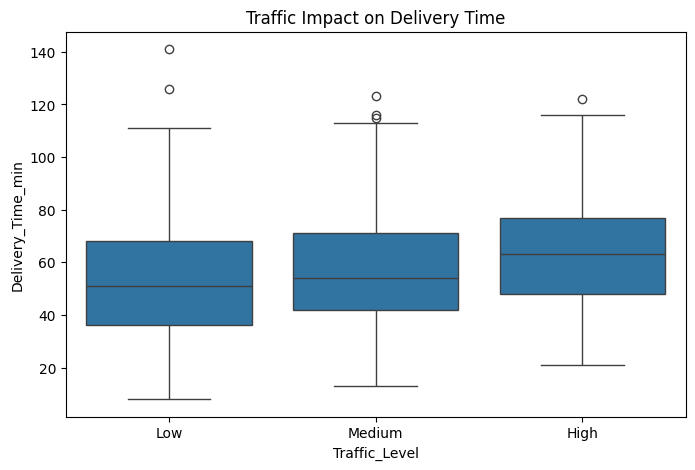

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df)
plt.title('Traffic Impact on Delivery Time')
plt.show()

In [9]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [10]:
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 7.048926553672316
RMSE: 9.812944869184262
R2 Score: 0.7644014276215612


In [12]:
df.to_csv('cleaned_food_delivery.csv', index=False)

In [13]:
from google.colab import files

files.download('cleaned_food_delivery.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>